Imports

In [1]:
#pip install pandas numpy scikit-learn matplotlib seaborn scipy nltk sentence-transformers

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA

from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import linkage, dendrogram

RANDOM_STATE = 42

Data Cleaning

In [2]:
rawcorpus_df = pd.read_csv("AllCorpus.csv")
print(f"Raw corpus: {len(rawcorpus_df)} documents")
rawcorpus_df.head()

Raw corpus: 650 documents


,doc_id,text,category_1,category_2,sentiment
0,1,Trump's presidency has been tattered with scan...,1,none,Negative
1,2,My machine learning course has been really enj...,2,none,Positive
2,3,The plot of the final season of The Boys has b...,3,none,Negative
3,4,I enjoy getting learning about strength traini...,4,none,Positive
4,5,It's concerning our government is partnering w...,1,2,Negative


In [3]:
df = rawcorpus_df.copy()

# --- Normalize sentiment ---
df["sentiment"] = df["sentiment"].str.strip().str.capitalize()
typo_map = {
    "Nuetral":  "Neutral",
    "Neutral.": "Neutral",
    "Positve":  "Positive",
    "Postive":  "Positive",
}
df["sentiment"] = df["sentiment"].replace(typo_map)

# --- Normalize category_2 ---
df["category_2"] = df["category_2"].astype(str).str.strip().str.lower()
df["category_2"] = df["category_2"].replace({"none": np.nan, "nan": np.nan})

# --- Drop invalid rows ---
# category_1 = -1 are placeholder rows; also drop rows missing sentiment
df = df[df["category_1"] != -1]
df = df[df["sentiment"].notna()]
df = df[df["text"].notna()]
df = df.reset_index(drop=True)

# --- Helper column ---
df["is_mixed"] = df["category_2"].notna()

print(f"Clean corpus: {len(df)} documents")
print(f"  Mixed-category docs : {df['is_mixed'].sum()}")
print(f"  Single-category docs: {(~df['is_mixed']).sum()}")
print()
print("Sentiment distribution:")
print(df["sentiment"].value_counts())
print()
print("Primary category distribution:")
print(df["category_1"].value_counts().sort_index())

Clean corpus: 639 documents
  Mixed-category docs : 319
  Single-category docs: 320

Sentiment distribution:
sentiment
Positive    230
Negative    211
Neutral     198
Name: count, dtype: int64

Primary category distribution:
category_1
1    168
2    140
3    129
4    117
5     85
Name: count, dtype: int64


In [4]:
category_names = {
    1: "News/Politics",
    2: "CS/Data Science",
    3: "Lit/Music/TV",
    4: "Health/Activity",
    5: "Food/Home/Pets",
}
df["category_label"] = df["category_1"].map(category_names)
df[["doc_id", "text", "category_1", "category_label", "sentiment", "is_mixed"]].head(8)

,doc_id,text,category_1,category_label,sentiment,is_mixed
0,1,Trump's presidency has been tattered with scan...,1,News/Politics,Negative,False
1,2,My machine learning course has been really enj...,2,CS/Data Science,Positive,False
2,3,The plot of the final season of The Boys has b...,3,Lit/Music/TV,Negative,False
3,4,I enjoy getting learning about strength traini...,4,Health/Activity,Positive,False
4,5,It's concerning our government is partnering w...,1,News/Politics,Negative,True
5,6,Modern workout apps are excellent in how they ...,2,CS/Data Science,Positive,True
6,7,Democrats will elect a strong candidate in 202...,1,News/Politics,Positive,False
7,8,Viewing a series for entertainment depends on ...,2,CS/Data Science,Neutral,True


Vectorization

In [5]:
bow_vectorizer    = CountVectorizer(stop_words="english")
binary_vectorizer = CountVectorizer(stop_words="english", binary=True)
tfidf_vectorizer  = TfidfVectorizer(stop_words="english")

X_bow    = bow_vectorizer.fit_transform(df["text"])
X_binary = binary_vectorizer.fit_transform(df["text"])
X_tfidf  = tfidf_vectorizer.fit_transform(df["text"])

print(f"Vocabulary size : {len(bow_vectorizer.vocabulary_)} terms")
print(f"BoW matrix shape: {X_bow.shape}")

# Preview the first 5 documents x first 12 vocabulary terms for each representation
bow_df    = pd.DataFrame(X_bow.toarray(),    columns=bow_vectorizer.get_feature_names_out())
binary_df = pd.DataFrame(X_binary.toarray(), columns=binary_vectorizer.get_feature_names_out())
tfidf_df  = pd.DataFrame(np.round(X_tfidf.toarray(), 3), columns=tfidf_vectorizer.get_feature_names_out())

print("Bag-of-Words (first 5 docs x 12 terms):")
display(bow_df.iloc[:5, :12])

print("\nBinary Presence (first 5 docs x 12 terms):")
display(binary_df.iloc[:5, :12])

print("\nTF-IDF (first 5 docs x 12 terms):")
display(tfidf_df.iloc[:5, :12])

Vocabulary size : 2970 terms
BoW matrix shape: (639, 2970)
Bag-of-Words (first 5 docs x 12 terms):


,10,100,111,12,20,2026,2028,30,5k,74,80,87
0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0



Binary Presence (first 5 docs x 12 terms):


,10,100,111,12,20,2026,2028,30,5k,74,80,87
0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0



TF-IDF (first 5 docs x 12 terms):


,10,100,111,12,20,2026,2028,30,5k,74,80,87
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Cosine Similarity Check

In [6]:
def show_similar_documents(X, vectorizer_name, query_index=0, top_n=3):
    sims = cosine_similarity(X[query_index], X).ravel()
    neighbours = np.argsort(sims)[::-1][1:top_n + 1]
    print(f"Query [{query_index}]: {df.loc[query_index, 'text'][:80]}...")
    print(f"Nearest documents using cosine similarity on {vectorizer_name}:")
    for nb in neighbours:
        print(f"  sim={sims[nb]:.3f} | doc {nb}: {df.loc[nb, 'text'][:80]}...")
    print()

# Query doc 105: "The artist Malcolm Todd generated a lot of social media buzz..."
show_similar_documents(X_bow,    "BoW",             query_index=105)
show_similar_documents(X_binary, "Binary Presence", query_index=105)
show_similar_documents(X_tfidf,  "TF-IDF",          query_index=105)

Query [105]: The artist Malcolm Todd generated a lot of social media buzz by playing a song f...
Nearest documents using cosine similarity on BoW:
  sim=0.229 | doc 82: The album got almost no attention at first, but the tracklist went viral through...
  sim=0.188 | doc 140: A recent review of the new Malcolm Todd album was highly positive because of his...
  sim=0.183 | doc 446: The author’s latest novel became a viral hit on social media....

Query [105]: The artist Malcolm Todd generated a lot of social media buzz by playing a song f...
Nearest documents using cosine similarity on Binary Presence:
  sim=0.188 | doc 140: A recent review of the new Malcolm Todd album was highly positive because of his...
  sim=0.188 | doc 82: The album got almost no attention at first, but the tracklist went viral through...
  sim=0.183 | doc 446: The author’s latest novel became a viral hit on social media....

Query [105]: The artist Malcolm Todd generated a lot of social media buzz by playing a son

what do i see here for malcolm :p

Phase 2 Supervised Learning

In [7]:
def plot_confusion(y_true, y_pred, title):
    """Plot a labelled confusion-matrix heatmap."""
    labels = sorted(pd.Series(list(y_true) + list(y_pred)).unique())
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


def evaluate_classifier(model, X, y, title, test_size=0.2):
    """
    Stratified train/test split, fit model, print metrics, show confusion matrix.
    Returns a summary dict for the results table.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print("=" * 70)
    print(title)
    print(f"Accuracy: {acc:.3f}")
    print(classification_report(y_test, y_pred, zero_division=0))
    plot_confusion(y_test, y_pred, title)

    return {"title": title, "accuracy": round(acc, 3)}


# Collect all results for the summary table
tasks = []

Task 1 Logistic Regression

Task 1 — Category Classification | LR on BoW
Accuracy: 0.805
                 precision    recall  f1-score   support

CS/Data Science       0.77      0.86      0.81        28
 Food/Home/Pets       0.62      0.47      0.53        17
Health/Activity       0.76      0.83      0.79        23
   Lit/Music/TV       0.88      0.85      0.86        26
  News/Politics       0.88      0.88      0.88        34

       accuracy                           0.80       128
      macro avg       0.78      0.78      0.78       128
   weighted avg       0.80      0.80      0.80       128



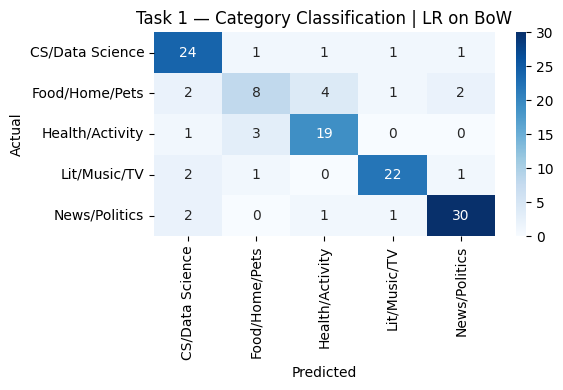

Task 1 — Category Classification | LR on TF-IDF
Accuracy: 0.773
                 precision    recall  f1-score   support

CS/Data Science       0.73      0.79      0.76        28
 Food/Home/Pets       0.71      0.29      0.42        17
Health/Activity       0.77      0.87      0.82        23
   Lit/Music/TV       0.84      0.81      0.82        26
  News/Politics       0.78      0.91      0.84        34

       accuracy                           0.77       128
      macro avg       0.77      0.73      0.73       128
   weighted avg       0.77      0.77      0.76       128



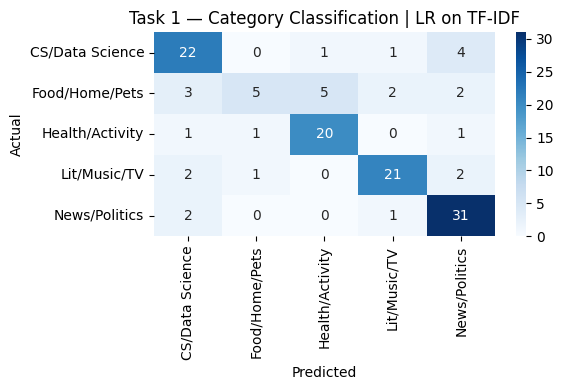

In [8]:
y_category = df["category_label"]

# Logistic Regression on BoW
tasks.append(evaluate_classifier(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_bow, y_category,
    "Task 1 — Category Classification | LR on BoW"
))

# Logistic Regression on TF-IDF
tasks.append(evaluate_classifier(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_tfidf, y_category,
    "Task 1 — Category Classification | LR on TF-IDF"
))

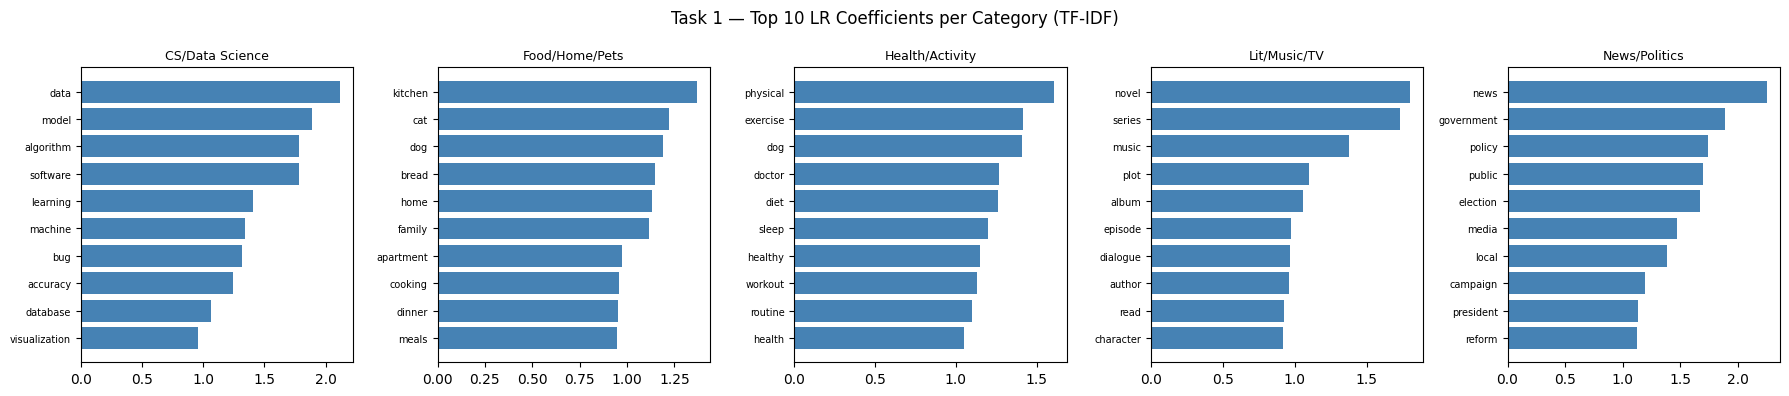

In [9]:
#visualizing yhr 10 most predictgive terms per category LR coff on tf-idf
lr_cat = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_cat.fit(X_tfidf, y_category)

feature_names = tfidf_vectorizer.get_feature_names_out()
fig, axes = plt.subplots(1, len(lr_cat.classes_), figsize=(18, 4), sharey=False)

for ax, cls_name, coefs in zip(axes, lr_cat.classes_, lr_cat.coef_):
    top_idx = np.argsort(coefs)[-10:]
    ax.barh(feature_names[top_idx], coefs[top_idx], color="steelblue")
    ax.set_title(cls_name, fontsize=9)
    ax.tick_params(axis="y", labelsize=7)

plt.suptitle("Task 1 — Top 10 LR Coefficients per Category (TF-IDF)", fontsize=12)
plt.tight_layout()
plt.show()

Task 2 KNN Sentiment

Task 2 — Sentiment Classification | kNN (cosine) on BoW
Accuracy: 0.578
              precision    recall  f1-score   support

    Negative       0.62      0.74      0.67        42
     Neutral       0.48      0.38      0.42        40
    Positive       0.60      0.61      0.60        46

    accuracy                           0.58       128
   macro avg       0.57      0.57      0.57       128
weighted avg       0.57      0.58      0.57       128



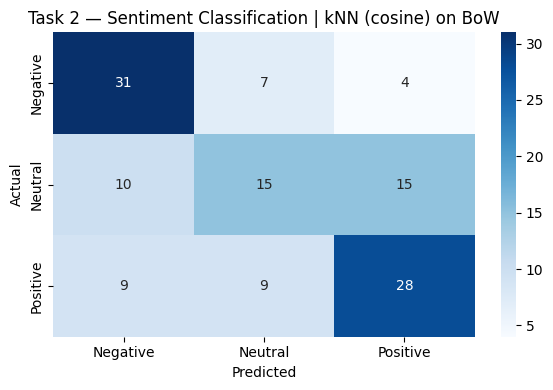

Task 2 — Sentiment Classification | kNN (cosine) on TF-IDF
Accuracy: 0.617
              precision    recall  f1-score   support

    Negative       0.60      0.83      0.70        42
     Neutral       0.63      0.47      0.54        40
    Positive       0.62      0.54      0.58        46

    accuracy                           0.62       128
   macro avg       0.62      0.62      0.61       128
weighted avg       0.62      0.62      0.61       128



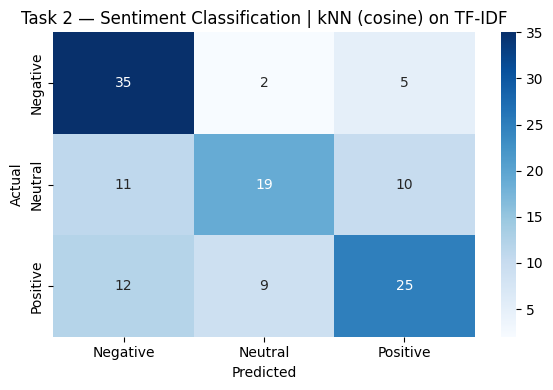

In [10]:
y_sentiment = df["sentiment"]

# kNN with cosine similarity on BoW
tasks.append(evaluate_classifier(
    KNeighborsClassifier(n_neighbors=5, metric="cosine"),
    X_bow, y_sentiment,
    "Task 2 — Sentiment Classification | kNN (cosine) on BoW"
))

# kNN with cosine similarity on TF-IDF
tasks.append(evaluate_classifier(
    KNeighborsClassifier(n_neighbors=5, metric="cosine"),
    X_tfidf, y_sentiment,
    "Task 2 — Sentiment Classification | kNN (cosine) on TF-IDF"
))

Task 2 — Sentiment Classification | kNN (cosine) on Binary Presence
Accuracy: 0.609
              precision    recall  f1-score   support

    Negative       0.68      0.76      0.72        42
     Neutral       0.53      0.45      0.49        40
    Positive       0.60      0.61      0.60        46

    accuracy                           0.61       128
   macro avg       0.60      0.61      0.60       128
weighted avg       0.60      0.61      0.60       128



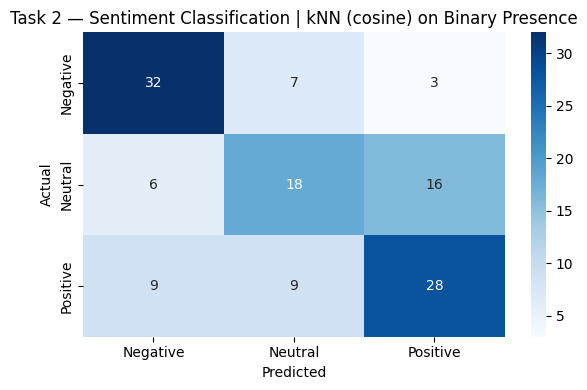

In [11]:
#cosine similarity vs biinary feature on KNN
tasks.append(evaluate_classifier(
    KNeighborsClassifier(n_neighbors=5, metric="cosine"),
    X_binary, y_sentiment,
    "Task 2 — Sentiment Classification | kNN (cosine) on Binary Presence"
))

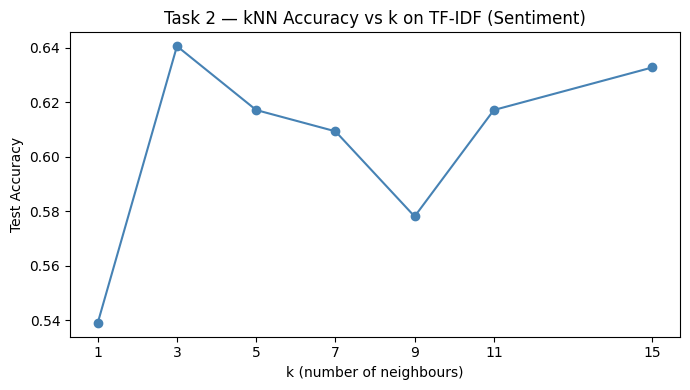

In [12]:
#finding the best k on tf-idf
X_tr, X_te, y_tr, y_te = train_test_split(
    X_tfidf, y_sentiment, test_size=0.2, random_state=RANDOM_STATE, stratify=y_sentiment
)

k_values = [1, 3, 5, 7, 9, 11, 15]
k_accs   = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric="cosine")
    knn.fit(X_tr, y_tr)
    k_accs.append(accuracy_score(y_te, knn.predict(X_te)))

plt.figure(figsize=(7, 4))
plt.plot(k_values, k_accs, marker="o", color="steelblue")
plt.xlabel("k (number of neighbours)")
plt.ylabel("Test Accuracy")
plt.title("Task 2 — kNN Accuracy vs k on TF-IDF (Sentiment)")
plt.xticks(k_values)
plt.tight_layout()
plt.show()

analysis
BoW vs TF-IDF
Knn benefits from TF-IDF because it reduces genereic words and emphasizes the unique vocab while logistic regression (LR) uses the raw word count in which the alhorithm assigns near-zero coefficients to irrelevamt or overly commonf eatures during trainign

tf-idf cosine similariry vs binary presence
idk yet

LR vs KNN
idk yet

**Unsupervised Learning: Random Foresting & Naive Bayes**

Task 3 — Random Forest

Task 3 — Category Classification | RF on BoW
Accuracy: 0.734
                 precision    recall  f1-score   support

CS/Data Science       0.73      0.79      0.76        28
 Food/Home/Pets       0.60      0.35      0.44        17
Health/Activity       0.81      0.91      0.86        23
   Lit/Music/TV       0.57      0.77      0.66        26
  News/Politics       0.93      0.74      0.82        34

       accuracy                           0.73       128
      macro avg       0.73      0.71      0.71       128
   weighted avg       0.75      0.73      0.73       128



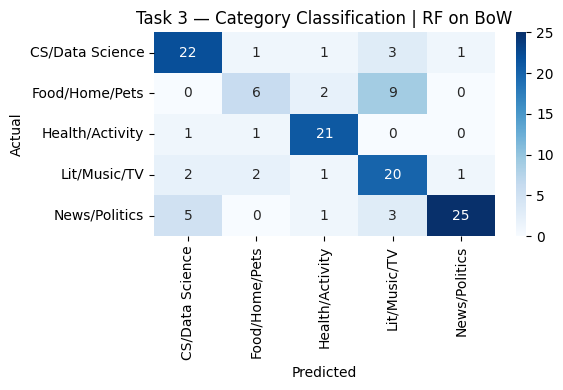

Task 3 — Category Classification | RF on TF-IDF
Accuracy: 0.742
                 precision    recall  f1-score   support

CS/Data Science       0.71      0.79      0.75        28
 Food/Home/Pets       0.60      0.35      0.44        17
Health/Activity       0.87      0.87      0.87        23
   Lit/Music/TV       0.59      0.85      0.70        26
  News/Politics       0.93      0.74      0.82        34

       accuracy                           0.74       128
      macro avg       0.74      0.72      0.72       128
   weighted avg       0.76      0.74      0.74       128



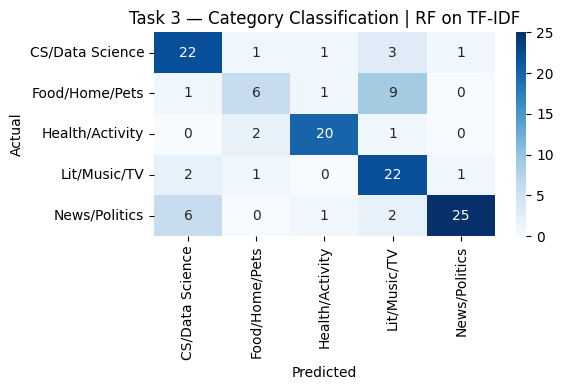

In [13]:
#I used Claude for drafting the code for random foresting
from sklearn.ensemble import RandomForestClassifier

# RF on BoW — category
tasks.append(evaluate_classifier(
    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    X_bow, y_category,
    "Task 3 — Category Classification | RF on BoW"
))

# RF on TF-IDF — category
tasks.append(evaluate_classifier(
    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    X_tfidf, y_category,
    "Task 3 — Category Classification | RF on TF-IDF"
))

**RF on TF-IDF vs RF on BoW showed little difference and the heatmap overall followed the same trend. Food/Home/Pets had the lowest classification accuracy compared to other categories.**

Task 3 — Sentiment Classification | RF on BoW
Accuracy: 0.789
              precision    recall  f1-score   support

    Negative       0.97      0.71      0.82        42
     Neutral       0.65      0.88      0.74        40
    Positive       0.84      0.78      0.81        46

    accuracy                           0.79       128
   macro avg       0.82      0.79      0.79       128
weighted avg       0.82      0.79      0.79       128



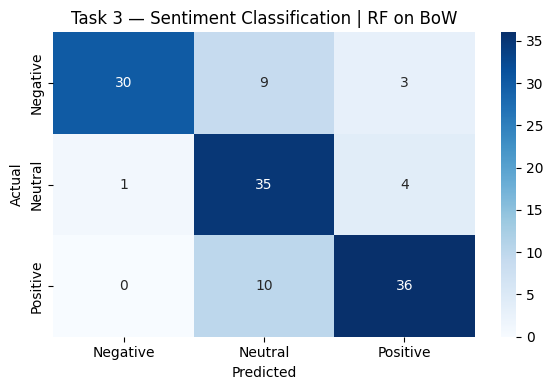

Task 3 — Sentiment Classification | RF on TF-IDF
Accuracy: 0.773
              precision    recall  f1-score   support

    Negative       0.97      0.69      0.81        42
     Neutral       0.60      0.88      0.71        40
    Positive       0.88      0.76      0.81        46

    accuracy                           0.77       128
   macro avg       0.82      0.78      0.78       128
weighted avg       0.82      0.77      0.78       128



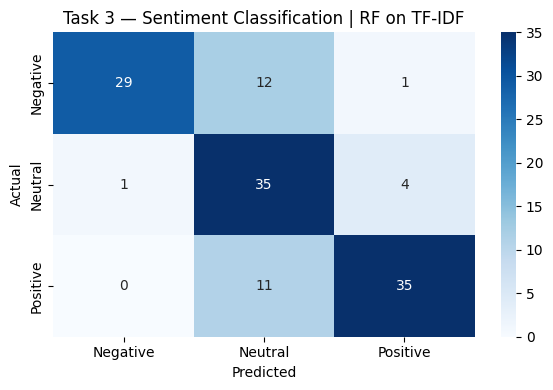

In [14]:
# RF on BoW — sentiment
tasks.append(evaluate_classifier(
    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    X_bow, y_sentiment,
    "Task 3 — Sentiment Classification | RF on BoW"
))

# RF on TF-IDF — sentiment
tasks.append(evaluate_classifier(
    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    X_tfidf, y_sentiment,
    "Task 3 — Sentiment Classification | RF on TF-IDF"
))

**For both BoW and TF-IDF the accuracy of sentiment classification overall followed the same trend.**

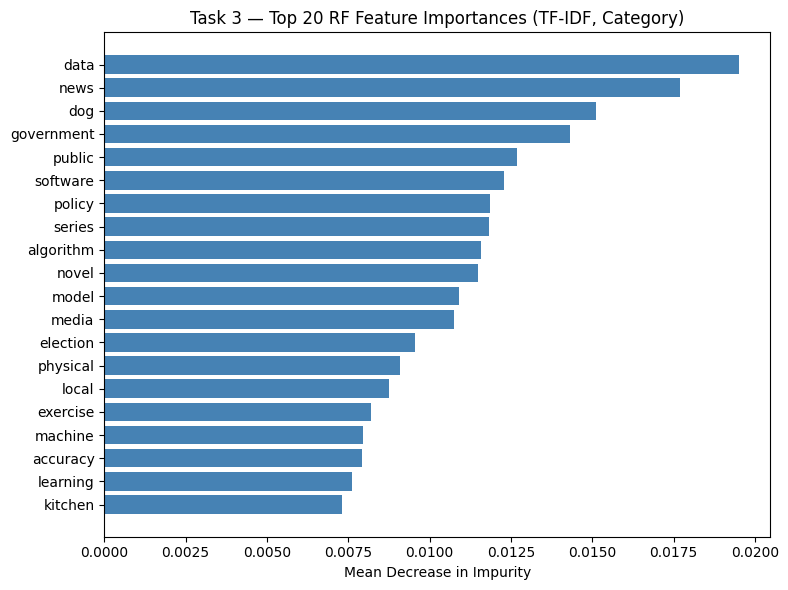

In [15]:
# Feature importances from a full-corpus RF (TF-IDF, category)
rf_cat = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_cat.fit(X_tfidf, y_category)

feature_names = tfidf_vectorizer.get_feature_names_out()
importances = rf_cat.feature_importances_
top_idx = np.argsort(importances)[-20:]

plt.figure(figsize=(8, 6))
plt.barh(feature_names[top_idx], importances[top_idx], color="steelblue")
plt.title("Task 3 — Top 20 RF Feature Importances (TF-IDF, Category)")
plt.xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

**Random foresting classifies by taking the overall average of a bunch of decision trees. The graph above shows the top 20 feature importances, this means the top 20 words used to split decisions in the trees. In other words, if data (the top feature) appears in the sentence it is gonna be more likely category 2 and make the tree more "pure". The mean decrease in impurity is how many caetgories we can eliminate from the possible categorization.**

**Overall conclusion: for RF there was not much difference between the results of using BoW or TF-IDF for converting the corpus into vectors. I find this surprising because I would believe that TF-IDF would always have a substantially higher accuracy compared to BoW because it feels more advanced and accurate. My hypothesis for why this is because I believe the corpus was a bit cheated, and since students when thinking of the categories for the document would purposely choose words ultra specific to those categories. This method of writing is unrealistic for real data, so I would like to test this again on real, unbiased data.**